In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool, cpu_count
import os
from scipy.optimize import curve_fit
from sage.all import EllipticCurve, QQ, primes_first_n, factor

#=======================
# SCAN PARAMETERS
#=======================

NUM_PRIMES = 1000
PRIMES = list(primes_first_n(NUM_PRIMES))
ALPHA_MAX = 50000

#=======================
# PHI VALUES TO SCAN
#=======================

PHI_VALUES = [
    (QQ(2)/QQ(9), '2/9', 'phi_2_9'),
    (QQ(-1), '-1', 'phi_m1'),
    (QQ(1)/QQ(2), '1/2', 'phi_1_2'),
    (QQ(1)/QQ(3), '1/3', 'phi_1_3'),
    (QQ(1)/QQ(4), '1/4', 'phi_1_4'),
    (QQ(1)/QQ(5), '1/5', 'phi_1_5'),
    (QQ(1)/QQ(6), '1/6', 'phi_1_6'),
    (QQ(1)/QQ(7), '1/7', 'phi_1_7'),
    (QQ(1)/QQ(8), '1/8', 'phi_1_8'),
    (QQ(1)/QQ(9), '1/9', 'phi_1_9'),
    (QQ(1)/QQ(10), '1/10', 'phi_1_10'),
]

#=======================
# FAMILY DEFINITIONS
#=======================

FAMILIES = {
    'Z2': {
        'family_name': r"$\mathbb{Z}/2\mathbb{Z}$",
        'family_form': r"$a = \alpha^2(\phi - 1/3),\; b = \frac{1}{27}\alpha^3(2 - 9\phi)$",
        'base_dir': 'MW_torsion_curves/Z2_quadratic_twists',
    },
    'Z2Z2': {
        'family_name': r"$\mathbb{Z}/2\mathbb{Z} \times \mathbb{Z}/2\mathbb{Z}$",
        'family_form': r"$a = \frac{\alpha^2}{3}(\phi - 1 - \phi^2),\; b = -\frac{\alpha^3}{27}(1+\phi)(1-2\phi)(2-\phi)$",
        'base_dir': 'MW_torsion_curves/Z2Z2_quadratic_twists',
    }
}

def get_curve_function(family_key, phi):
    """Return the appropriate curve constructor for the family."""
    if family_key == 'Z2':
        def elliptic_curve_from_alpha(alpha):
            alpha = QQ(alpha)
            a = alpha**2 * (phi - QQ(1)/QQ(3))
            b = QQ(1)/QQ(27) * alpha**3 * (2 - 9*phi)
            return EllipticCurve(QQ, [a, b])
    elif family_key == 'Z2Z2':
        def elliptic_curve_from_alpha(alpha):
            alpha = QQ(alpha)
            a = (alpha**2 / 3) * (phi - 1 - phi**2)
            b = -(alpha**3 / 27) * (1 + phi) * (1 - 2*phi) * (2 - phi)
            return EllipticCurve(QQ, [a, b])
    return elliptic_curve_from_alpha

#=======================
# HELPER FUNCTIONS
#=======================

def is_squarefree(n):
    """Check if n is square-free."""
    if n == 0:
        return False
    for p, e in factor(abs(n)):
        if e >= 2:
            return False
    return True

def get_squarefree_values(max_val):
    """Get all square-free integers from 1 to max_val."""
    return [n for n in range(1, max_val + 1) if is_squarefree(n)]

def power_law(x, A, alpha):
    return A / (x**alpha)

# Global variable for multiprocessing
_curve_func = None

def init_worker(family_key, phi):
    """Initialize worker with curve function."""
    global _curve_func
    _curve_func = get_curve_function(family_key, phi)

def process_alpha(alpha):
    """Process a single square-free alpha value. Returns dict or None."""
    global _curve_func
    try:
        E = _curve_func(alpha)
        E_min = E.minimal_model()
        N = int(E_min.conductor())
        
        # Compute isogeny class directly
        iso_class = E_min.isogeny_class()
        rep = iso_class.curves[0].minimal_model()
        iso_key = tuple(int(a) for a in rep.a_invariants())
        iso_size = len(iso_class.curves)
        
        # Rank computation
        rk = int(E_min.rank())
        
        # Frobenius traces
        ap_list = [int(E_min.ap(p)) for p in PRIMES]
        
        return {'alpha': alpha, 'conductor': N, 'iso_key': iso_key, 
                'iso_size': iso_size, 'rank': rk, 'ap_list': ap_list}
    except Exception as e:
        print(f"Error alpha={alpha}: {e}")
        return None

#=======================
# MAIN LOOP OVER FAMILIES AND PHI VALUES
#=======================

all_alphas = get_squarefree_values(ALPHA_MAX)

for family_key, fam in FAMILIES.items():
    
    FAMILY_NAME = fam['family_name']
    FAMILY_FORM = fam['family_form']
    BASE_DIR = fam['base_dir']
    
    for PHI, PHI_EXACT, PHI_FOLDER in PHI_VALUES:
        
        OUTPUT_DIR = f'{BASE_DIR}/{PHI_FOLDER}'
        PHI_STR = fr"$\phi = {PHI_EXACT}$"
        
        print(f"\n{'='*70}")
        print(f"Processing: {family_key} torsion, phi = {PHI_EXACT}")
        print(f"Output: {OUTPUT_DIR}")
        print(f"{'='*70}\n")
        
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        
        # ====================================================================
        # SCAN AND PROCESS
        # ====================================================================
        
        print(f"Processing {len(all_alphas)} square-free alpha values up to {ALPHA_MAX}...")
        
        with Pool(processes=cpu_count(), initializer=init_worker, initargs=(family_key, PHI)) as pool:
            results = list(tqdm(pool.imap(process_alpha, all_alphas), total=len(all_alphas)))
        
        # Filter successful results
        results = [r for r in results if r is not None]
        print(f"Successfully processed {len(results)} curves")
        
        if len(results) == 0:
            print(f"No valid curves for {family_key} with phi={PHI_EXACT}, skipping...")
            continue
        
        # ====================================================================
        # BUILD DATABASE
        # ====================================================================
        
        alpha_to_iso = {}
        iso_to_alphas = {}
        iso_to_data = {}
        
        for r in results:
            alpha, iso_key = r['alpha'], r['iso_key']
            alpha_to_iso[alpha] = iso_key
            
            if iso_key not in iso_to_alphas:
                iso_to_alphas[iso_key] = []
                iso_to_data[iso_key] = {
                    'conductor': r['conductor'],
                    'ap_list': r['ap_list'],
                    'iso_size': r['iso_size'],
                    'rank': r['rank'],
                    'alpha_rep': alpha
                }
            iso_to_alphas[iso_key].append(alpha)
        
        # Extract unique isogeny class data
        isogeny_classes = list(iso_to_data.keys())
        alpha_reps = [iso_to_data[iso]['alpha_rep'] for iso in isogeny_classes]
        conductors = [iso_to_data[iso]['conductor'] for iso in isogeny_classes]
        ap_lists = [iso_to_data[iso]['ap_list'] for iso in isogeny_classes]
        iso_sizes = [iso_to_data[iso]['iso_size'] for iso in isogeny_classes]
        ranks = [iso_to_data[iso]['rank'] for iso in isogeny_classes]
        
        multiplicities_by_iso = {iso: len(alphas) for iso, alphas in iso_to_alphas.items()}
        
        print(f"Found {len(isogeny_classes)} distinct isogeny classes")
        print(f"Conductor range: [{min(conductors)}, {max(conductors)}]")
        
        # ====================================================================
        # COMPUTE AVERAGE FROBENIUS TRACES (OVERALL AND BY RANK)
        # ====================================================================
        
        ap_array = np.array(ap_lists)
        avg_frob_traces = np.mean(ap_array, axis=0)
        std_frob_traces = np.std(ap_array, axis=0)
        
        rank_to_indices = {}
        for i, rk in enumerate(ranks):
            if rk not in rank_to_indices:
                rank_to_indices[rk] = []
            rank_to_indices[rk].append(i)
        
        avg_frob_by_rank = {}
        std_frob_by_rank = {}
        count_by_rank = {}
        
        for rk, indices in rank_to_indices.items():
            rk_traces = np.array([ap_lists[i] for i in indices])
            avg_frob_by_rank[rk] = np.mean(rk_traces, axis=0)
            std_frob_by_rank[rk] = np.std(rk_traces, axis=0)
            count_by_rank[rk] = len(indices)
            print(f"Rank {rk}: {count_by_rank[rk]} isogeny classes")
        
        # ====================================================================
        # SAVE DATA
        # ====================================================================
        
        print("Saving data...")
        scan_data = {
            'family': family_key,
            'phi': float(PHI),
            'phi_exact': PHI_EXACT,
            'family_form': FAMILY_FORM,
            'all_alphas': all_alphas,
            'alpha_reps': alpha_reps,
            'isogeny_classes': isogeny_classes,
            'conductors': conductors,
            'ranks': ranks,
            'ap_lists': ap_lists,
            'iso_sizes': iso_sizes,
            'alpha_to_iso': alpha_to_iso,
            'iso_to_alphas': iso_to_alphas,
            'iso_to_data': iso_to_data,
            'multiplicities_by_iso': multiplicities_by_iso,
            'avg_frob_traces': avg_frob_traces.tolist(),
            'std_frob_traces': std_frob_traces.tolist(),
            'avg_frob_by_rank': {rk: arr.tolist() for rk, arr in avg_frob_by_rank.items()},
            'std_frob_by_rank': {rk: arr.tolist() for rk, arr in std_frob_by_rank.items()},
            'count_by_rank': count_by_rank,
            'primes': PRIMES,
            'alpha_max': ALPHA_MAX,
            'num_isogeny_classes': len(isogeny_classes),
            'num_alphas_processed': len(results)
        }
        save(scan_data, f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_scan_data.sobj')
        
        # ====================================================================
        # PLOTTING
        # ====================================================================
        
        print("Creating plots...")
        sqrt_primes = np.sqrt(PRIMES)
        
        # 1. Multiplicity vs alpha
        processed_alphas = [alpha for alpha in all_alphas if alpha in alpha_to_iso]
        processed_mults = [multiplicities_by_iso[alpha_to_iso[alpha]] for alpha in processed_alphas]
        
        plt.figure(figsize=(14, 7))
        scatter = plt.scatter(processed_alphas, processed_mults, c=processed_mults, cmap='plasma',
                              alpha=0.6, s=15, edgecolors='none')
        plt.colorbar(scatter, label='Multiplicity')
        plt.xlabel(r'$\alpha$', fontsize=14)
        plt.ylabel(r'Multiplicity (# $\alpha$ → same isogeny class)', fontsize=14)
        plt.title(f'{FAMILY_NAME} torsion: Isogeny class multiplicity vs $\\alpha$\n{PHI_STR}, square-free $\\alpha \\leq {ALPHA_MAX}$', fontsize=14)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Multiplicity = 1')
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_multiplicity_vs_alpha.png', dpi=150)
        plt.close()
        
        # 2. alpha_rep distribution
        plt.figure(figsize=(12, 6))
        plt.hist(alpha_reps, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        plt.xlabel(r'$\alpha$ representative', fontsize=14)
        plt.ylabel('Count', fontsize=14)
        plt.title(f'{FAMILY_NAME} torsion: Distribution of $\\alpha$ representatives\n{PHI_STR}, {len(alpha_reps)} unique isogeny classes', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_alpha_rep_distribution.png', dpi=150)
        plt.close()
        
        # 3. Conductor vs alpha_rep
        plt.figure(figsize=(12, 7))
        plt.scatter(alpha_reps, conductors, c=np.log10(conductors), cmap='viridis', 
                    alpha=0.6, s=20, edgecolors='none')
        plt.colorbar(label=r'$\log_{10}(N)$')
        plt.xlabel(r'$\alpha$ representative', fontsize=14)
        plt.ylabel(r'Conductor $N$', fontsize=14)
        plt.title(f'{FAMILY_NAME} torsion: Conductor vs $\\alpha$ representative\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$', fontsize=14)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_conductor_vs_alpha.png', dpi=150)
        plt.close()
        
        # 4. Conductor distribution
        plt.figure(figsize=(14, 6))
        counts_N, bins_N, _ = plt.hist(conductors, bins=100, density=True, alpha=0.6, label='Data')
        bin_centers = (bins_N[:-1] + bins_N[1:]) / 2
        mask = counts_N > 0
        
        try:
            popt, _ = curve_fit(power_law, bin_centers[mask], counts_N[mask], p0=[1e6, 1.5], maxfev=10000)
            A_fit, beta_fit = popt
            x_fit = np.linspace(min(conductors), max(conductors), 1000)
            plt.plot(x_fit, power_law(x_fit, A_fit, beta_fit), 'r-', linewidth=2,
                     label=fr'Power law: $\beta={beta_fit:.3f}$')
        except Exception as e:
            print(f"Power law fit failed: {e}")
        
        plt.xlabel(r"Conductor $N$", fontsize=12)
        plt.ylabel("Density", fontsize=12)
        plt.title(f"{FAMILY_NAME} torsion: Conductor distribution\n{PHI_STR}, square-free $\\alpha \\leq {ALPHA_MAX}$", fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_conductor_distribution.png', dpi=150)
        plt.close()
        
        # 5. Multiplicity histogram
        mult_counts = {}
        for m in multiplicities_by_iso.values():
            mult_counts[m] = mult_counts.get(m, 0) + 1
        
        plt.figure(figsize=(12, 6))
        mult_vals = sorted(mult_counts.keys())
        mult_freqs = [mult_counts[m] for m in mult_vals]
        plt.bar(mult_vals, mult_freqs, color='teal', edgecolor='black', alpha=0.7)
        plt.xlabel('Multiplicity', fontsize=14)
        plt.ylabel('Number of isogeny classes', fontsize=14)
        plt.title(f'{FAMILY_NAME} torsion: Isogeny class multiplicities\n{PHI_STR}, square-free $\\alpha \\leq {ALPHA_MAX}$', fontsize=14)
        plt.grid(True, alpha=0.3, linestyle='--', axis='y')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_multiplicity_histogram.png', dpi=150)
        plt.close()
        
        # 6. Average Frobenius traces by rank
        plt.figure(figsize=(14, 7))
        colors = plt.cm.tab10(np.linspace(0, 1, max(len(avg_frob_by_rank), 1)))
        for i, rk in enumerate(sorted(avg_frob_by_rank.keys())):
            plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[rk], alpha=0.6, s=10, 
                        color=colors[i], label=f'Rank {rk} (n={count_by_rank[rk]})')
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.legend(fontsize=12)
        plt.xlabel(r"Prime index $i$", fontsize=12)
        plt.ylabel(r"Average Frobenius trace $\langle a_{p_i} \rangle$", fontsize=12)
        plt.title(f"{FAMILY_NAME} torsion: Average Frobenius traces by rank\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_avg_frobenius_traces_by_rank.png', dpi=150)
        plt.close()
        
        # 7. Overall average Frobenius traces
        plt.figure(figsize=(14, 7))
        plt.scatter(range(NUM_PRIMES), avg_frob_traces, alpha=0.6, s=10, 
                    label=f'Average (n={len(ap_lists)} classes)')
        plt.fill_between(range(NUM_PRIMES), 
                         avg_frob_traces - std_frob_traces, 
                         avg_frob_traces + std_frob_traces, 
                         alpha=0.2, label='±1 std dev')
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.legend(fontsize=12)
        plt.xlabel(r"Prime index $i$", fontsize=12)
        plt.ylabel(r"Average Frobenius trace $\langle a_{p_i} \rangle$", fontsize=12)
        plt.title(f"{FAMILY_NAME} torsion: Overall average Frobenius traces\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_avg_frobenius_traces.png', dpi=150)
        plt.close()
        
        # 8. Rank 0 vs Rank 1 Frobenius traces
        if 0 in avg_frob_by_rank and 1 in avg_frob_by_rank:
            plt.figure(figsize=(14, 7))
            plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[0], alpha=0.6, s=12,
                        color='blue', label=f'Rank 0 (n={count_by_rank[0]})')
            plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[1], alpha=0.6, s=12,
                        color='red', label=f'Rank 1 (n={count_by_rank[1]})')
            plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            plt.legend(fontsize=12)
            plt.xlabel(r"Prime index $i$", fontsize=12)
            plt.ylabel(r"Average Frobenius trace $\langle a_{p_i} \rangle$", fontsize=12)
            plt.title(f"{FAMILY_NAME} torsion: Rank 0 vs Rank 1 Frobenius traces\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$", fontsize=14)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_frobenius_rank0_vs_rank1.png', dpi=150)
            plt.close()
            
            # Normalized version
            plt.figure(figsize=(14, 7))
            plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[0] / sqrt_primes, alpha=0.6, s=12,
                        color='blue', label=f'Rank 0 (n={count_by_rank[0]})')
            plt.scatter(range(NUM_PRIMES), avg_frob_by_rank[1] / sqrt_primes, alpha=0.6, s=12,
                        color='red', label=f'Rank 1 (n={count_by_rank[1]})')
            plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            plt.legend(fontsize=12)
            plt.xlabel(r"Prime index $i$", fontsize=12)
            plt.ylabel(r"$\langle a_{p_i} \rangle / \sqrt{p_i}$", fontsize=12)
            plt.title(f"{FAMILY_NAME} torsion: Rank 0 vs Rank 1 normalized\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$", fontsize=14)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_normalized_rank0_vs_rank1.png', dpi=150)
            plt.close()
        else:
            print("Warning: Need both rank 0 and rank 1 curves for comparison plot")
        
        # 9. Normalized Frobenius traces
        plt.figure(figsize=(14, 7))
        plt.scatter(range(NUM_PRIMES), avg_frob_traces / sqrt_primes, alpha=0.6, s=10)
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.xlabel(r"Prime index $i$", fontsize=12)
        plt.ylabel(r"$\langle a_{p_i} \rangle / \sqrt{p_i}$", fontsize=12)
        plt.title(f"{FAMILY_NAME} torsion: Normalized average Frobenius traces\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_normalized_frobenius_traces.png', dpi=150)
        plt.close()
        
        # 10. Normalized by rank
        plt.figure(figsize=(14, 7))
        for i, rk in enumerate(sorted(avg_frob_by_rank.keys())):
            normalized = avg_frob_by_rank[rk] / sqrt_primes
            plt.scatter(range(NUM_PRIMES), normalized, alpha=0.6, s=10,
                        color=colors[i], label=f'Rank {rk} (n={count_by_rank[rk]})')
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.legend(fontsize=12)
        plt.xlabel(r"Prime index $i$", fontsize=12)
        plt.ylabel(r"$\langle a_{p_i} \rangle / \sqrt{p_i}$", fontsize=12)
        plt.title(f"{FAMILY_NAME} torsion: Normalized Frobenius by rank\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_normalized_frobenius_by_rank.png', dpi=150)
        plt.close()
        
        # 11. Isogeny class size distribution
        plt.figure(figsize=(12, 6))
        size_counts = {}
        for s in iso_sizes:
            size_counts[s] = size_counts.get(s, 0) + 1
        sizes = sorted(size_counts.keys())
        size_freqs = [size_counts[s] for s in sizes]
        plt.bar(sizes, size_freqs, color='coral', edgecolor='black', alpha=0.7)
        plt.xlabel('Isogeny class size', fontsize=14)
        plt.ylabel('Number of isogeny classes', fontsize=14)
        plt.title(f'{FAMILY_NAME} torsion: Isogeny class sizes\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$', fontsize=14)
        plt.grid(True, alpha=0.3, linestyle='--', axis='y')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_isogeny_class_sizes.png', dpi=150)
        plt.close()
        
        # 12. Rank distribution
        plt.figure(figsize=(12, 6))
        rank_vals = sorted(count_by_rank.keys())
        rank_counts = [count_by_rank[r] for r in rank_vals]
        plt.bar(rank_vals, rank_counts, color='mediumpurple', edgecolor='black', alpha=0.7)
        plt.xlabel('Rank', fontsize=14)
        plt.ylabel('Number of isogeny classes', fontsize=14)
        plt.title(f'{FAMILY_NAME} torsion: Rank distribution\n{PHI_STR}, $\\alpha \\leq {ALPHA_MAX}$', fontsize=14)
        plt.grid(True, alpha=0.3, linestyle='--', axis='y')
        for rv, rc in zip(rank_vals, rank_counts):
            plt.text(rv, rc + max(rank_counts)*0.02, str(rc), ha='center', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/alpha_max_{ALPHA_MAX}_rank_distribution.png', dpi=150)
        plt.close()
        
        print(f"\nSummary ({FAMILY_NAME} torsion, phi = {PHI_EXACT}):")
        print(f"  alpha_max: {ALPHA_MAX}")
        print(f"  Square-free alpha values: {len(all_alphas)}")
        print(f"  Successfully processed: {len(results)}")
        print(f"  Unique isogeny classes: {len(isogeny_classes)}")
        print(f"  Conductor range: [{min(conductors)}, {max(conductors)}]")
        print(f"  Rank distribution: {dict(sorted(count_by_rank.items()))}")

print(f"\n{'='*70}")
print("All families and phi values processed!")
print(f"{'='*70}")

In [1]:
scan_data = load('MW_torsion_curves/Z2_quadratic_twists/phi_1_5/alpha_max_5000_scan_data.sobj')

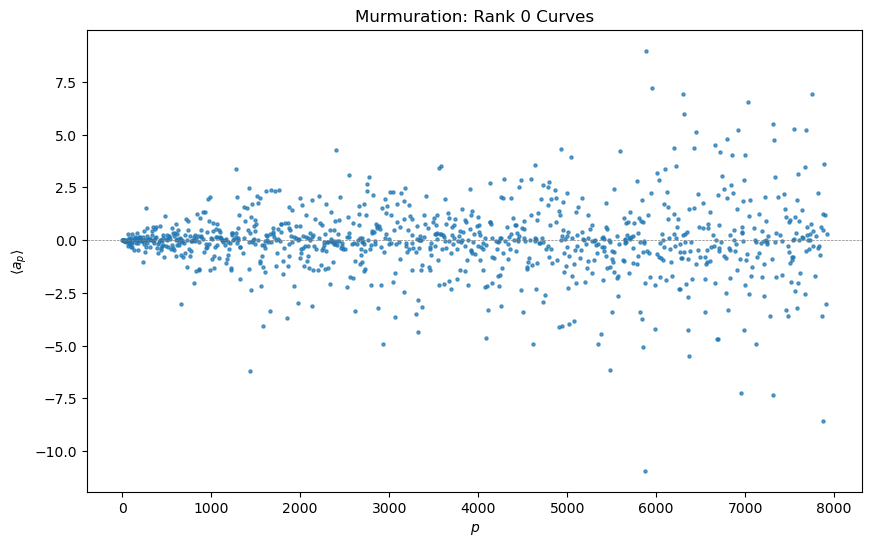

In [2]:
import matplotlib.pyplot as plt

primes = primes_first_n(1000)
avg_ap = scan_data['avg_frob_by_rank'][0]

plt.figure(figsize=(10, 6))
plt.scatter(primes, avg_ap, s=5, alpha=0.7)
plt.xlabel(r'$p$')
plt.ylabel(r'$\langle a_p \rangle$')
plt.title('Murmuration: Rank 0 Curves')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.show()

In [7]:
EllipticCurve([0,0,0,2**(1/2),0])

Elliptic Curve defined by y^2 = x^3 + sqrt(2)*x over Symbolic Ring